In [1]:
from google.colab import files
uploaded = files.upload()

Saving BestSeller Books of Amazon.csv to BestSeller Books of Amazon.csv


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
import os
os.listdir()

['.config', 'BestSeller Books of Amazon.csv', 'sample_data']

In [28]:
df = pd.read_csv("BestSeller Books of Amazon.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Book Name    400 non-null    object 
 1   Author Name  400 non-null    object 
 2   Rating       400 non-null    float64
 3   Price        400 non-null    object 
dtypes: float64(1), object(3)
memory usage: 12.6+ KB


In [29]:
df["Price"].head(10)
df["Price"].unique()

array(['₹239.00', '₹299.00', '₹476.00', '₹399.00', '₹209.00', '₹149.00',
       '₹348.00', '₹177.00', '₹460.00', '₹274.00', '₹369.00', '₹899.00',
       '₹595.00', '₹199.00', '₹150.00', '₹98.00', '₹739.00', '₹97.00',
       '₹435.00', '₹137.00', '₹247.00', '₹220.00', '₹297.00', '₹330.00',
       '₹372.00', '₹110.00', '₹170.00', '₹324.35', '₹594.00', '₹329.00',
       '₹183.00', '₹410.00', '₹349.00', '₹375.00', '₹88.00', '₹182.00',
       '₹370.00', '₹550.00', '₹189.00', '₹200.00', '₹1,357.00', '₹135.00',
       '₹306.00', '₹548.00'], dtype=object)

In [30]:
df["Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Price"] = df["Price"].str.replace(",", "", regex=False)
df["Price"] = df["Price"].astype(float)

df["Price"].head(10)

,Price
0,239.0
1,299.0
2,476.0
3,399.0
4,209.0
5,149.0
6,348.0
7,177.0
8,460.0
9,274.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Book Name    400 non-null    object 
 1   Author Name  400 non-null    object 
 2   Rating       400 non-null    float64
 3   Price        400 non-null    float64
dtypes: float64(2), object(2)
memory usage: 12.6+ KB


In [32]:
conn = sqlite3.connect("bestsellers.db")
df.to_sql("books", conn, if_exists="replace", index=False)

400

In [33]:
df.duplicated().sum()

np.int64(350)

In [34]:
df = df.drop_duplicates()
print(f"{len(df)} rows remain after removing duplicates")

50 rows remain after removing duplicates


In [35]:
df.to_sql("books", conn, if_exists="replace", index=False)

50

average price and rating overall

In [36]:
q1 = """
SELECT
    ROUND(AVG(Price), 2) AS avg_price,
    ROUND(AVG(Rating), 2) AS avg_rating,
    COUNT(*) AS total_books
FROM books
"""
df1 = pd.read_sql_query(q1, conn)
df1

,avg_price,avg_rating,total_books
0,330.67,4.46,50


Rating vs Price relationship

In [37]:
q2 = """
SELECT
    CASE
        WHEN Price < 100 THEN 'Under 100'
        WHEN Price BETWEEN 100 AND 300 THEN '100-300'
        WHEN Price BETWEEN 301 AND 500 THEN '301-500'
        ELSE '500+'
    END AS price_range,
    ROUND(AVG(Rating), 2) AS avg_rating,
    COUNT(*) AS num_books
FROM books
GROUP BY price_range
ORDER BY avg_rating DESC
"""
df2 = pd.read_sql_query(q2, conn)
df2

,price_range,avg_rating,num_books
0,100-300,4.50,23
1,500+,4.43,7
2,301-500,4.43,17
3,Under 100,4.40,3


Top Author

In [38]:
q3 = """
SELECT
    "Author Name",
    COUNT(*) AS num_books,
    ROUND(AVG(Rating), 2) AS avg_rating
FROM books
GROUP BY "Author Name"
ORDER BY num_books DESC
LIMIT 10
"""
df3 = pd.read_sql_query(q3, conn)
df3

,Author Name,num_books,avg_rating
0,Wonder House Books,7,4.44
1,Maple Press,3,4.43
2,MTG Editorial Board,2,4.40
3,Joseph Murphy,2,4.50
4,Dale Carnegie,2,4.50
5,Tirth Raj Parsana,1,3.60
6,Team Pegasus,1,4.60
7,Susmita Dhar Kriti Arora,1,4.20
8,Sudha Murty,1,4.60
9,Sank Magic,1,4.00


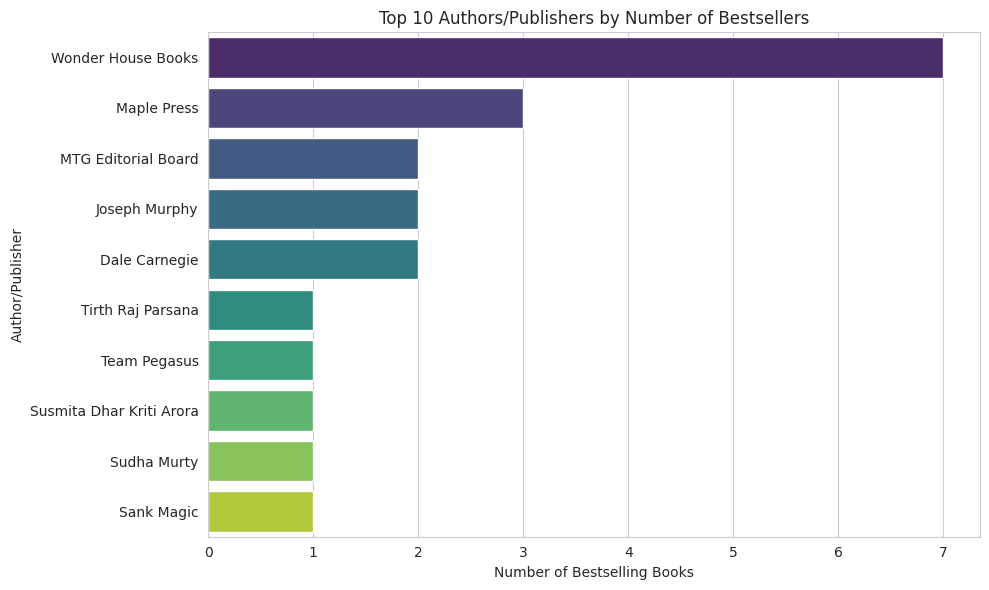

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df3, x="num_books", y="Author Name", hue="Author Name", palette="viridis", legend=False)
plt.title("Top 10 Authors/Publishers by Number of Bestsellers")
plt.xlabel("Number of Bestselling Books")
plt.ylabel("Author/Publisher")
plt.tight_layout()
plt.savefig("top_authors.png", dpi=150)
plt.show()

Top-rated individual books

In [40]:
q4 = """
SELECT
    "Book Name",
    "Author Name",
    Rating,
    Price
FROM books
ORDER BY Rating DESC
LIMIT 10
"""
df4 = pd.read_sql_query(q4, conn)
df4

,Book Name,Author Name,Rating,Price
0,Shrimad Bhagwat Geeta Yatharoop (Hindi),A.C. Bhaktivendanta Swami Prabhupada,4.8,200.0
1,Maths Concept King All Formulas and Theorum | ...,Gagan Pratap Sir,4.7,239.0
2,PW Calculus Core Fear No More Calculus Book By...,Sachin Jakhar,4.7,460.0
3,All In One English Core class 12th Based On La...,Prerna Kain Srishti Agarwal,4.7,370.0
4,Atomic Habits : the life-changing million-copy...,James Clear,4.6,476.0
5,Ikigai,Francesc Miralles,4.6,348.0
6,The Psychology of Money,Morgan Housel,4.6,274.0
7,Indian Polity for UPSC (English)|7th Edition|C...,M Laxmikanth,4.6,739.0
8,1001 Ultimate Brain Booster Activities for 4+ ...,Team Pegasus,4.6,297.0
9,Grandma's Bag of Stories: Collection of 20+ Il...,Murty Sudha,4.6,199.0


In [41]:
from google.colab import files
files.download("top_authors.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>